Code and Data Preprocessing by Dautrevaux Cyprien and Matthieu Gilson

Data from Garrido et al. J Neurophysiol 2009 (doi:10.1152/jn.90291.2008)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.getcwd()

# si la fin du path contient scripts, on remonte d'un niveau

if os.getcwd().endswith('scripts'):
    os.chdir('..')
   
os.getcwd()
 
    

'd:\\DATA\\Projets\\M1_EEG_Project'

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.000038,0.000033,0.000010,0.000024,1.294136e-05,3.112182e-05,0.000011,0.000026,-0.051268,-0.773196,0.596669,65024.0,2.345948,-0.717714,-0.959071,-1.605406
1,0.000036,0.000033,0.000010,0.000023,1.141392e-05,2.987441e-05,0.000021,0.000026,-0.079824,-0.782596,-1.322676,65024.0,0.659690,0.209444,-0.605627,1.572219
2,0.000035,0.000033,0.000011,0.000023,1.125399e-05,2.821593e-05,0.000015,0.000025,1.213708,0.221438,-0.827384,65024.0,0.255079,-0.251640,0.516812,-1.911218
3,0.000035,0.000031,0.000013,0.000023,1.124820e-05,2.756447e-05,0.000007,0.000027,-0.430032,-1.586872,1.062746,65024.0,1.228781,0.495350,2.006143,-0.824715
4,0.000035,0.000028,0.000012,0.000022,9.858593e-06,2.693874e-05,0.000010,0.000030,0.397535,0.574432,-0.639049,65024.0,-0.853590,-1.165458,0.185660,-0.296324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0.000013,0.000005,-0.000008,-0.000022,-1.113086e-06,-3.981343e-06,-0.000004,-0.000022,1.316461,1.067206,1.391563,65024.0,-1.564078,-0.365124,0.885102,-0.751644
149996,0.000010,0.000003,-0.000006,-0.000023,-1.378080e-06,-9.041445e-07,0.000012,-0.000010,-1.395090,-0.505514,-0.956260,65024.0,0.498653,0.713156,-1.475210,1.305408
149997,0.000011,0.000002,-0.000005,-0.000022,-1.193433e-06,9.930802e-07,0.000016,-0.000007,-0.189028,0.862373,0.221955,65024.0,-0.021844,0.476402,0.308003,-2.248821
149998,0.000012,0.000003,-0.000004,-0.000021,-5.368889e-07,-3.056807e-07,0.000003,-0.000013,0.480199,2.191716,0.348920,65024.0,0.319019,0.591511,1.080635,0.159009


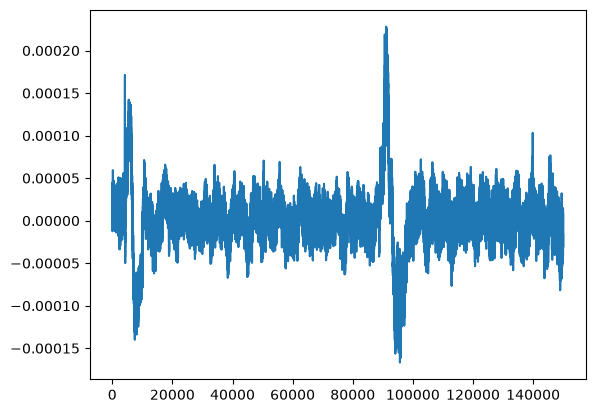

In [2]:
# get data from csv file
df = pd.read_csv('data/EEG_ses.csv', sep='\t', header=None)

# example trace
plt.plot(df[7])
df

In [3]:
df.index.size

150000

In [4]:
# sampling rate is 512 Hz
vt = np.arange(df.index.size) / 512.0 # transform index in samples to time in seconds

the stimulus timing data in col. 11

Text(0.5, 0, 'time (s)')

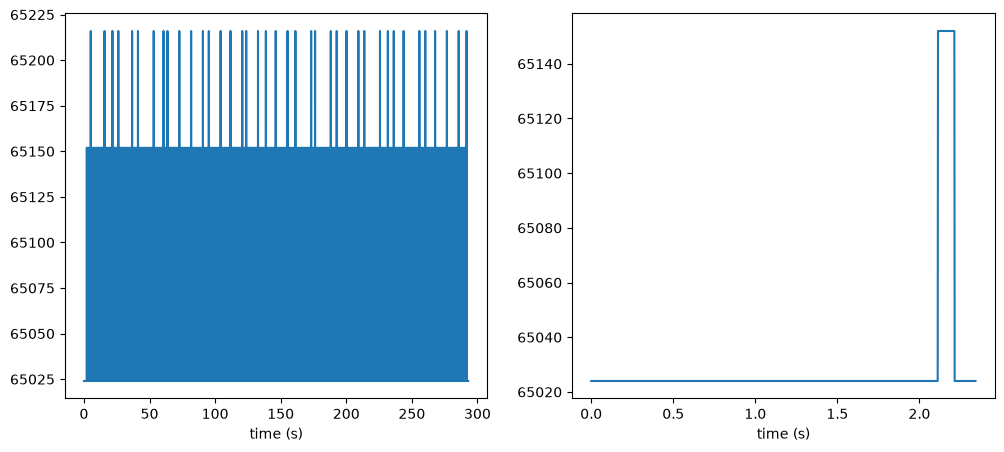

In [5]:
ts_stim = df[11]

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].plot(vt, ts_stim)
axs[0].set_xlabel('time (s)')
axs[1].plot(vt[:1200], ts_stim[:1200])
axs[1].set_xlabel('time (s)')

detection of onset using the functino diff (derivative)
we extract the time when the derivative > 0

(0.0, 2000.0)

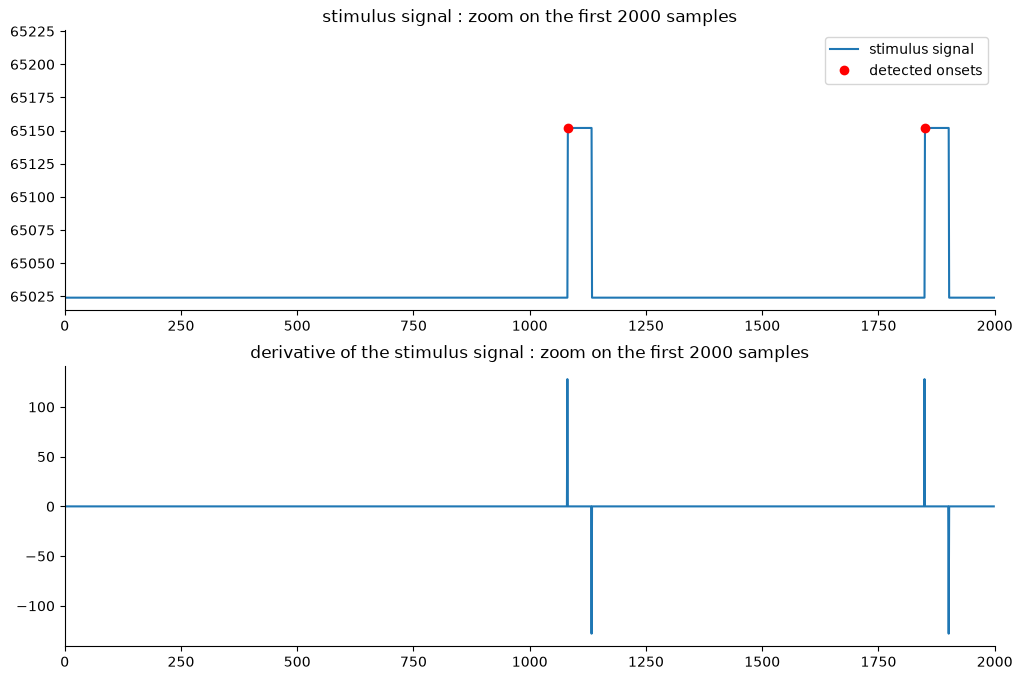

In [50]:
onsets = np.where(np.diff(ts_stim) > 0)[0] + 1

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(ts_stim)
ax[0].set_title('stimulus signal : zoom on the first 2000 samples')
ax[0].plot(onsets, ts_stim[onsets], 'ro')
ax[0].set_xlim(0, 2000)
ax[0].legend(['stimulus signal', 'detected onsets'])
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].plot(np.diff(ts_stim[0:2000]))
ax[1].set_title('derivative of the stimulus signal : zoom on the first 2000 samples')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_xlim(0, 2000)







In [51]:
# extraction of epochs for stimulus
stim_epochs = []

for t in onsets:
    stim_epochs.append(ts_stim[t-25:t+125])

stim_epochs = np.array(stim_epochs)
print(stim_epochs.shape)
stim_epochs = stim_epochs.T
print(stim_epochs.shape)

(194, 150)
(150, 194)


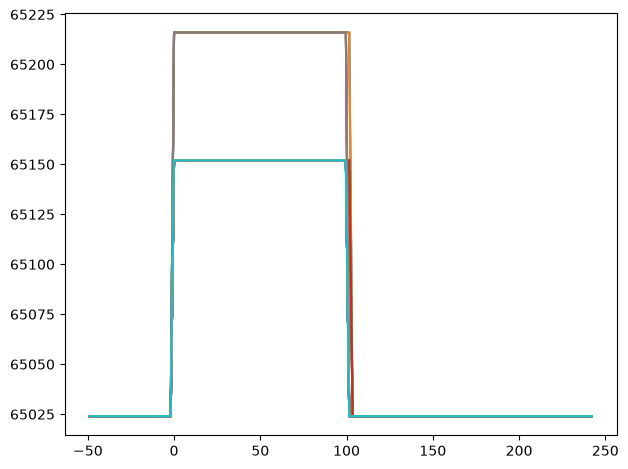

In [8]:
vt = np.arange(-25,125) * 1000.0 / 512.0 # in ms

plt.plot(vt, stim_epochs[:,:50])
plt.tight_layout()

In [9]:
# extraction of epochs for a given channel
i_ch = 3

sensor_epochs = []

for t in onsets:
    sensor_epochs.append(df[i_ch][t-25:t+125])

sensor_epochs = np.array(sensor_epochs)
sensor_epochs = sensor_epochs.T
print(sensor_epochs.shape)

(150, 194)


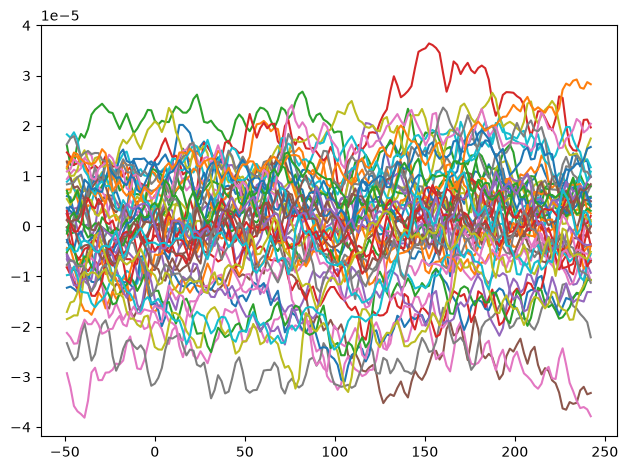

In [10]:
plt.plot(vt, sensor_epochs[:,:50])
plt.tight_layout()

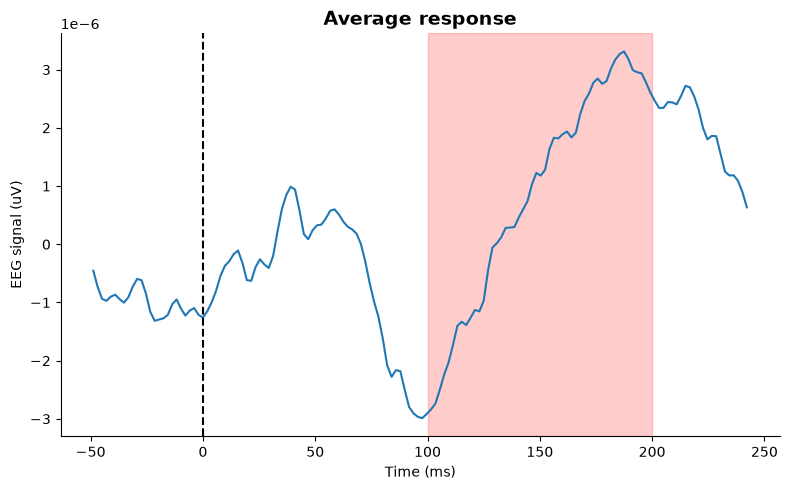

In [54]:
# average response
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(vt, sensor_epochs[:,:].mean(axis=1))
ax.set_xlabel('Time (ms)')
ax.set_ylabel('EEG signal (uV)')
ax.axvline(x=0, color='k', linestyle='--')
ax.axvspan(100, 200, color='r', alpha=0.2)
ax.set_title('Average response' , fontsize=14,weight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()